# Simulated IRF from RBC Model

This code creates a very simple RBC model with random technology shocks. Data from this model is simulated, the true IRFs are created, and then the IRFs are estimated using VAR and SLP estimation. For simplicity the only random variable is technology and it is assumed that the econometrician observes all three variables (consumption, capital, technology shocks) perfectly.

In [1]:
# import packages
import statsmodels as sm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

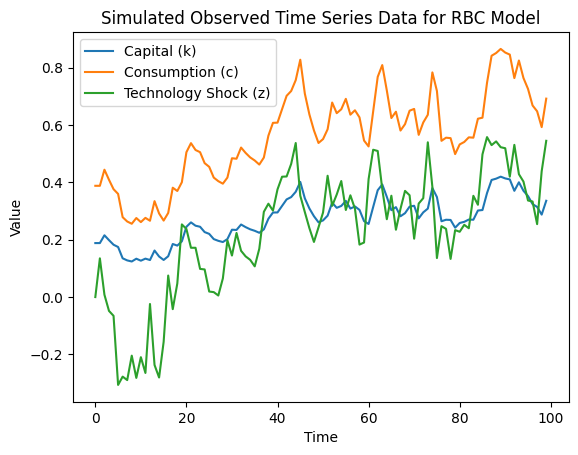

In [2]:
# create simulated time series data for simple RBC model (log utility, Cobb-Douglas production function, inelastic labor supply, full depreciation)
np.random.seed(4812)
def gen_macro_ts(beta, alpha, rho, sigma, T):
    z_ss = 0
    ss_k = (1/(beta*alpha))**(1/(alpha-1))
    ss_c = np.exp(z_ss)*ss_k**alpha - ss_k
    k = np.zeros(T)
    c = np.zeros(T)
    z = np.zeros(T)
    k[0] = ss_k
    c[0] = ss_c
    z[0] = z_ss
    for t in range(1, T):
        z[t] = rho * z[t-1] + sigma * np.random.normal()
        k[t] = alpha * beta * np.exp(z[t-1]) * k[t-1]**alpha
        c[t] = (1-alpha*beta) * np.exp(z[t-1]) * k[t-1]**alpha
    return pd.DataFrame({"k": k, "c": c, "z": z})

observed_data = gen_macro_ts(beta=0.99, alpha=0.33, rho = 0.9, sigma = 0.1, T=100)
plt.plot(observed_data)
plt.title("Simulated Observed Time Series Data for RBC Model")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend(["Capital (k)", "Consumption (c)", "Technology Shock (z)"])
plt.show()

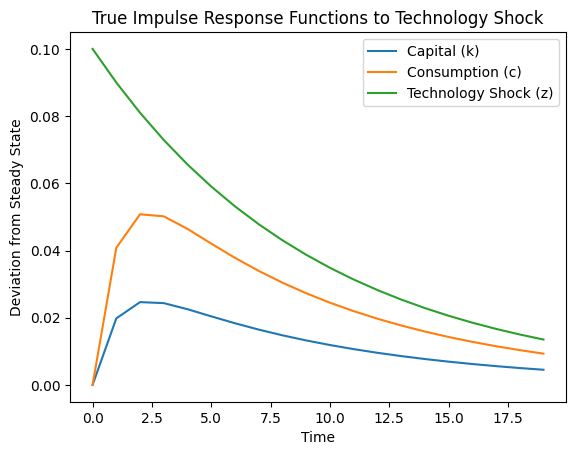

In [3]:
# simulated IRF for technology shock based on RBC model 
# this is the true IRF that the econometrician is trying to estimate from the observed data
def gen_irf(beta, alpha, rho, sigma, T):
    ss_k = (1/(beta*alpha))**(1/(alpha-1))
    ss_c = ss_k**alpha - ss_k
    k = np.zeros(T)
    c = np.zeros(T)
    z = np.zeros(T)
    k[0] = ss_k
    c[0] = ss_c
    z[0] = sigma # shock at time 0
    for t in range(1, T):
        z[t] = rho * z[t-1]
        k[t] = alpha * beta * np.exp(z[t-1]) * k[t-1]**alpha
        c[t] = (1-alpha*beta) * np.exp(z[t-1]) * k[t-1]**alpha
    k = k - ss_k
    c = c - ss_c
    return pd.DataFrame({"k": k, "c": c, "z": z})

true_irf = gen_irf(beta=0.99, alpha=0.33, rho = 0.9, sigma = 0.1, T=20)
plt.plot(true_irf)
plt.title("True Impulse Response Functions to Technology Shock")
plt.xlabel("Time")
plt.ylabel("Deviation from Steady State")
plt.legend(["Capital (k)", "Consumption (c)", "Technology Shock (z)"])
plt.show()

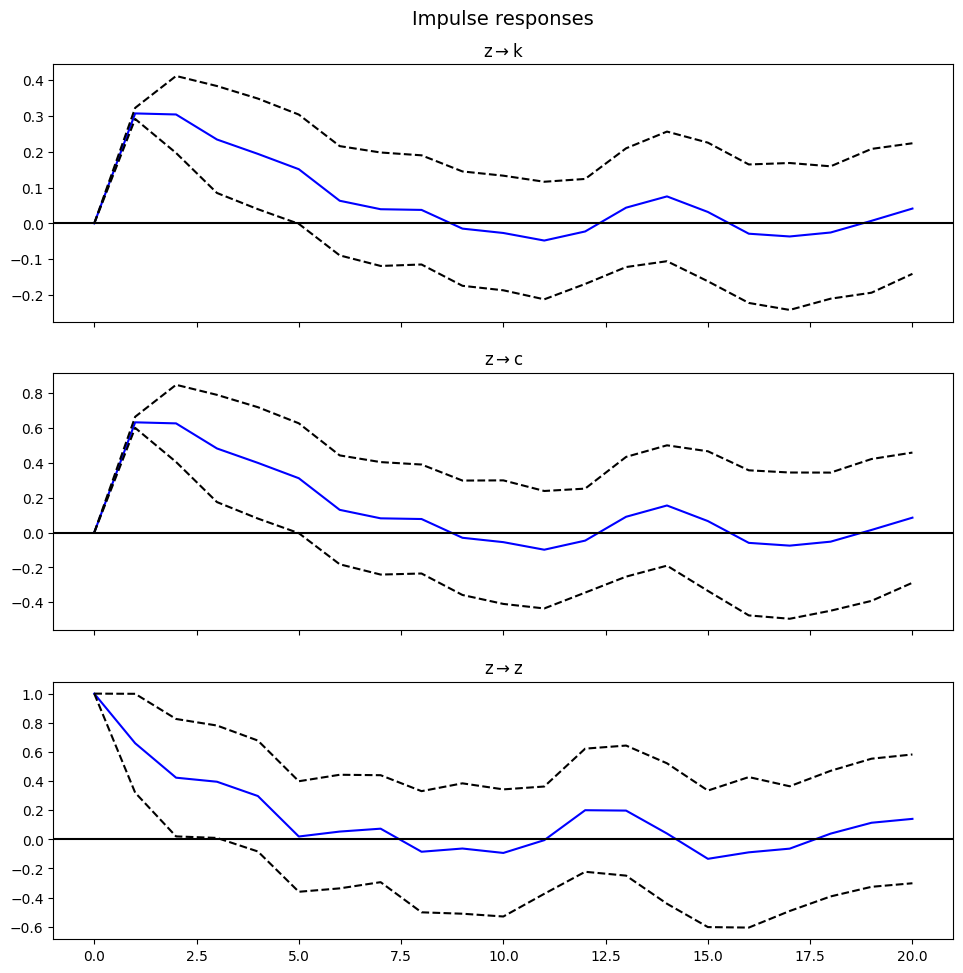

In [11]:
# estimated IRF using VAR model on observed data
from statsmodels.tsa.api import VAR
def estimate_irf(data, T):
    model = VAR(data)
    results = model.fit(16)
    irf = results.irf(T)
    return irf
VAR_irf = estimate_irf(observed_data, T=20)
VAR_irf.plot(orth=False, impulse = "z")
plt.show()